In [ ]:
import os
import ast
import pandas as pd
import random
import csv
from typing import Literal
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langchain_anthropic import ChatAnthropic
from langgraph.prebuilt import create_react_agent
from langgraph.graph import StateGraph, END
from langgraph.graph import MessagesState
from pydantic import BaseModel, Field

# Set API key manually
os.environ["ANTHROPIC_API_KEY"] = ""

MAX_SENTENCES = 2
CSV_FILE = "approved_sentences.csv"

In [26]:
train_set_16 = pd.read_csv('//home/s6moakba/InstructABSA/Dataset/SemEval16/Train/Restaurants_Train.csv')
train_set_16['aspectTerms'] = train_set_16['aspectTerms'].apply(ast.literal_eval)
train_set_16['aspect'] = train_set_16['aspectTerms'].apply(lambda x: [d['term'] for d in x])
train_set_16['polarity'] = train_set_16['aspectTerms'].apply(lambda x: [d['polarity'] for d in x])
training_terms = set(aspect for sublist in train_set_16['aspect'] for aspect in sublist)
training_terms.discard('noaspectterm')

In [27]:
train_set_16

,raw_text,aspectTerms,aspect,polarity
0,Judging from previous posts this used to be a ...,"[{'term': 'place', 'polarity': 'negative'}]",[place],[negative]
1,"We, there were four of us, arrived at noon - t...","[{'term': 'staff', 'polarity': 'negative'}]",[staff],[negative]
2,"They never brought us complimentary noodles, i...","[{'term': 'noaspectterm', 'polarity': 'none'}]",[noaspectterm],[none]
3,The food was lousy - too sweet or too salty an...,"[{'term': 'food', 'polarity': 'negative'}, {'t...","[food, portions]","[negative, negative]"
4,"After all that, they complained to me about th...","[{'term': 'noaspectterm', 'polarity': 'none'}]",[noaspectterm],[none]
...,...,...,...,...
1995,"I can't believe that it was, but please put th...","[{'term': 'noaspectterm', 'polarity': 'none'}]",[noaspectterm],[none]
1996,The waitress came to check in on us every few ...,"[{'term': 'waitress', 'polarity': 'negative'}]",[waitress],[negative]
1997,I couldn't ignore the fact that she reach over...,"[{'term': 'noaspectterm', 'polarity': 'none'}]",[noaspectterm],[none]
1998,She then put the check down without asking if ...,"[{'term': 'noaspectterm', 'polarity': 'none'}]",[noaspectterm],[none]


In [28]:
# polarity_lengths = train_set_16['polarity'].apply(len)
# polarity_lengths_distribution = polarity_lengths.value_counts()
# print(polarity_lengths_distribution)

In [29]:
training_polarities =  ['negative', 'positive', 'neutral','negative', 'positive', 'negative', 'positive']

In [30]:
llm = ChatAnthropic(
    model="claude-3-5-sonnet-latest",
    api_key=os.getenv("ANTHROPIC_API_KEY"),
    temperature=0.2,
    max_tokens=1024
)

In [31]:
import random
def get_aspect():
        label_len = random.randint(2, 3)
        aspec_terms = random.sample(list(training_terms),label_len)
        polarities = random.sample(training_polarities,label_len)
        terms = [aspec_terms,polarities]
        return terms

In [32]:
class SentenceGen(BaseModel):
    sentence: str = Field(None, description="The generated sentence.")
    Terms: list = Field(None, description="The aspect term used.")
    Polarity: list = Field(None, description="The polarity of the aspect term.")

structured_llm_gen = llm.with_structured_output(SentenceGen)

In [33]:
class SentenceEval(BaseModel):
    Eval: Literal['OK', 'NOT_OK'] = Field(None, description="Evaluation result.")

structured_llm_eval = llm.with_structured_output(SentenceEval)

In [34]:
@tool
def generate_sentences() -> str:
    """Generates a sentence containing an aspect term."""
    terms = get_aspect()
    aspect_term = terms[0]
    polarity = terms[1]
    print('Selected terms:', aspect_term)
    print('Selected polarities:', polarity)
    prompt = f"""Generate a sentence using this aspect term: {', '.join(aspect_term)} with the following polarities : {', '.join(polarity)}.
    - Examples : 
    - ['food', 'portions'] ['negative', 'negative']
    - The food was lousy - too sweet or too salty and the portions tiny.
    - Bad Example : 
    - ['soup'],['positive']
    - The udon soup was rich and flavorful (correct term was soup)
    Respond **only** with the sentence. Do not include explanations."""
    response = structured_llm_gen.invoke(prompt)
    print('Sentence generated')
    return response


# @tool
# def fix_sentence(text: str) -> str:
#     """Fixes a sentence based on evaluator feedback."""
#     print('Fixing sentence')
#     prompt = f"""Improve the following sentence based on the provided feedback but keep the initial aspect term and polarity.:
#     {text}
#     Respond **only** with the improved sentence. Do not include explanations."""
#     fixed_sentence = llm.invoke(prompt)
#     return fixed_sentence.content.strip()

# Evaluator tool
@tool
def evaluate_sentence(text: str) -> str:
    """
    Evaluates if the provided aspect terms are correctly present in the sentence.
    Responds only with 'OK' or 'NOT_OK'.
    """
    print('Evaluating sentence')
    prompt = f"""
    You are an expert in linguistic evaluation. Your task is to check if the given aspect terms are correct for the provided sentence.
    
    - If ALL aspect terms appear as actual aspects in the sentence, respond **only** with: OK
    - If any term is missing, incorrect, or not an aspect of the sentence, respond **only** with: NOT_OK

    Do not provide explanations or any other text.

    Input:
    {text}
    """
    return structured_llm_eval.invoke(prompt)

In [ ]:
#  Examples :  
#    - The food was lousy - too sweet or too salty and the portions tiny. ['food', 'portions'] ['negative', 'negative'] 
#    - OK 
#    - The spicy tuna roll was disappointing and lacked any real flavor.' ['spicy tuna roll'] ['negative']
#    - OK
#    - "The udon soup was rich and flavorful, perfectly warming me up on a cold day.",['soup'],['positive']
#    - NOT_OK. [correct term is 'udon soup']
#    Respond strictly in the following format:
#     - If everything is correct: "OK"
#     - If anything is incorrect: "NOT_OK. [feedback]

In [35]:
generator_agent = create_react_agent(
    llm,
    tools=[generate_sentences],
    prompt="""You are a sentence generator. You can generate a new sentence.
            generate_sentences` to create a new sentence."""
)

evaluator_agent = create_react_agent(
    llm,
    tools=[evaluate_sentence],
    prompt="You are an evaluator. Your task is to determine if the given aspect terms are correct for the sentence."
    "TO evaluate, use the `evaluate_sentence` tool. Tool expects a string that includes:  1. sentence 2. aspect terms 3. polarities."
    " Respond strictly with 'OK' if all terms are correct, or 'NOT_OK' if any term is incorrect."
    " Do not provide explanations or any other text."
)

In [23]:
import re

def generator_node(state: MessagesState):
    """Node for generating or fixing sentences."""
    print('in generator node')
    # last_message = state["messages"][-1] if state["messages"] else None

    # if last_message and last_message.name == "evaluator":
    #     # Feedback detected, generator should fix the sentence
    #     result = generator_agent.invoke({"messages": [HumanMessage(content=last_message.content)]})
    # else:
    #     # No feedback, generate a new sentence
    result = generator_agent.invoke({"messages": [HumanMessage(content="Generate a new sentence.")]})

    result["messages"][-1] = HumanMessage(content=result["messages"][-1].content, name="generator")
    print('generator node result:', result["messages"][-2].content)
    return {"messages": result["messages"]}

def evaluator_node(state: MessagesState):
    """Node that evaluates the generated sentence."""
    print('in evaluator node')
    generated_sentence = state["messages"][-2].content
    eval_input = {"messages": [HumanMessage(content=generated_sentence)]}

    result = evaluator_agent.invoke(eval_input)

    eval_response = result["messages"][-1].content
    print('evaluation response: ',eval_response)

    if eval_response not in ["OK", "NOT_OK"]:
        print("[Evaluator Node] Invalid response from LLM. Defaulting to NOT_OK.")
        eval_response = "NOT_OK"


    if eval_response == "OK":
        final_sentence = state["messages"][-2].content  
        return {"messages": state["messages"] + [HumanMessage(content=f"Final Approved Sentence: {final_sentence}", name="evaluator")]}

    return {"messages": state["messages"] + [HumanMessage(content="NOT_OK", name="evaluator")]}

def saver_node(state: MessagesState):
    """Node that saves the final approved sentence and its aspect term to a CSV file."""
    print('in saver node')
    last_message = state["messages"][-1].content

    if last_message.startswith("Final Approved Sentence:"):
        final_sentence = last_message.replace("Final Approved Sentence: ", "").strip()
    else:
        return {"messages": state["messages"]}

    message_content = last_message.replace("Final Approved Sentence: ", "").strip()

    # Extract aspect term using regex (Assuming it follows a pattern like Terms='some term')
    if " Terms=" in message_content:
        sentence_part, remaining_part = message_content.split(" Terms=", 1)
        terms_part, polarity_part = remaining_part.split(" Polarity=", 1)
        
        # Remove sentence='...' structure
        final_sentence = sentence_part.replace("sentence=", "").strip().strip("'\"")
        aspect_term = terms_part.strip().strip("'\"")
        polarity = polarity_part.strip().strip("'\"")
    else:
        # Fallback if splitting fails
        final_sentence = message_content.strip().strip("'\"")
        aspect_term = "Unknown Terms"
        polarity = "Unknown Polarity"

    csv_file = "approved_sentences.csv"

    # Ensure the file has headers if it does not exist
    file_exists = os.path.isfile(csv_file)

    with open(csv_file, mode='a', newline='', encoding='utf-8') as file:
        writer = csv.writer(file)
        if not file_exists:
            writer.writerow(["sentence", "Terms", "Polarity"])  # Write headers if new file
        writer.writerow([final_sentence, aspect_term, polarity])

    print(f"[Saver Node] Sentence saved: {final_sentence} | Aspect Term: {aspect_term}")

    confirmation_message = HumanMessage(content="Sentence successfully saved.", name="saver")
    return {"messages": state["messages"] + [confirmation_message]}

def evaluation_decision(state: MessagesState):
    """Decides whether to loop back to generator or proceed to saver node."""
    print('in sentence evaluation decision')
    last_message = state["messages"][-1].content.strip()

    if last_message.startswith("Final Approved Sentence:"):
        return "saver"  # Route to saver_node

    return "generator"


In [24]:
def save_decision(state: MessagesState):
    """Decides whether to continue generating sentences or stop based on saved sentence count."""
    print('in continuing  decision')
    if os.path.isfile(CSV_FILE):
        df = pd.read_csv(CSV_FILE)
        sentence_count = len(df)
        if sentence_count < MAX_SENTENCES:
            return "generator"  # Keep generating sentences
    else:
        return "generator"  # If no file exists, continue generating

    return END

In [13]:
# Build the graph
graph = StateGraph(MessagesState)

graph.add_node("generator", generator_node)
graph.add_node("evaluator", evaluator_node)
graph.add_node("saver", saver_node)  

graph.set_entry_point("generator")  # Entry point

graph.add_edge("generator", "evaluator")
graph.add_conditional_edges("evaluator", evaluation_decision, {"generator": "generator", "saver": "saver"})
# graph.add_edge("saver", END)  # Saver node leads to END
graph.add_conditional_edges("saver", save_decision, {"generator": "generator", END: END})

# graph.add_conditional_edges("saver", continue_decision, {"generator": "generator", END: END})

graph = graph.compile()

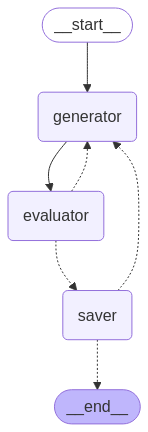

In [14]:
from IPython.display import clear_output
from IPython.display import Image
clear_output(wait=True)  # Clear previous outputs
display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
messages = graph.invoke({"messages": [ HumanMessage(content="Generate sentences for me using your agents.")]},{"recursion_limit": 150})
for m in messages["messages"]:
    m.pretty_print()

in generator node
Selected terms: ["Water's Edge", 'patio']
Selected polarities: ['negative', 'positive']
Sentence generated
generator node result: sentence="While Water's Edge was disappointing overall, their patio offered a lovely outdoor dining experience." Terms=["Water's Edge", 'patio'] Polarity=['negative', 'positive']
in evaluator node
Evaluating sentence
evaluation response:  OK
in sentence evaluation decision
in saver node
[Saver Node] Sentence saved: While Water's Edge was disappointing overall, their patio offered a lovely outdoor dining experience. | Aspect Term: ["Water's Edge", 'patio']
in continuing  decision
================================ Human Message =================================

Generate sentences for me using your agents.
================================ Human Message =================================

Generate a new sentence.
================================== Ai Message ==================================

[{'text': "I'll help you generate a new sentence usi